# ReforesTree 🌴

We are excited to share with you the ReforesTree dataset! 🎉
We introduce the ReforesTree dataset in hopes of encouraging the fellow machine learning community to take on
the challenge of developing low-cost, scalable, trustworthy and accurate solutions for monitoring, verification and reporting of tropical reforestation inventory. 

#### This is a dataset for the following 6 agroforestry sites
In alphabetical order
1. _Carlos Vera Arteaga_
2. _Carlos Vera Guevara_
3. _Flora Pluas_
4. _Leonor Aspiazu_
5. _Manuel Macias_
6. _Nestor Macias_


## Dataset Components
For each site the data we publish consists of four components free for use:
1. 🛸 Raw drone RGB images _(see wwf_ecuador/"Name of site")_
2. 🌴 Hand measured tree parameters (diameter at breast height, species, biomass, and location) of every tree _(see field_data.csv)_
3. 🔲 Set of bounding boxes of trees for each site cleaned by hand and labeled as banana or not banana _(see annotations/cleaned)_
4. ↔️ Mappings of these bounding boxes with tree labels based on location _(see mappings/final)_


## Tutorial
In this tutorial we go through the steps to recreate (and hopefully improve) the dataset and how to use it. 

Please read our paper [here](https://arxiv.org/abs/2201.11192).
For any questions, please reach out to gyri.reiersen@tum.de or david.dao@inf.eth.ch

## Load packages and modules

In [2]:
!pip install -Ur requirements.txt

  Using cached POT-0.8.1.0-cp37-cp37m-macosx_10_9_x86_64.whl (189 kB)
     |████████████████████████████████| 11.0 MB 5.5 MB/s eta 0:00:01    |████████████████████▎           | 7.0 MB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 16.9 MB 24.5 MB/s eta 0:00:01
     |████████████████████████████████| 1.0 MB 25.8 MB/s eta 0:00:01
     |████████████████████████████████| 21.1 MB 13.2 MB/s eta 0:00:01�█▉         | 15.1 MB 26.5 MB/s eta 0:00:01     |██████████████████████████████  | 19.8 MB 13.2 MB/s eta 0:00:01
     |████████████████████████████████| 7.3 MB 18.4 MB/s eta 0:00:01     |████▌                           | 1.0 MB 18.4 MB/s eta 0:00:01     |██████▎                         | 1.4 MB 18.4 MB/s eta 0:00:01     |███████████████████████         | 5.2 MB 18.4 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 5.4 MB/s eta 0:00:01
     |████████████████████████████████| 582 kB 10.1 MB/s eta 0:00:01
     |████████████████████████████████| 129.9 MB 13 kB/s  eta 0:

  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.0
    Uninstalling typing-extensions-3.10.0.0:
      Successfully uninstalled typing-extensions-3.10.0.0
  Attempting uninstall: torch
    Found existing installation: torch 1.9.0
    Uninstalling torch-1.9.0:
      Successfully uninstalled torch-1.9.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.0
    Uninstalling numpy-1.20.0:
      Successfully uninstalled numpy-1.20.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 1.14.0
    Uninstalling tensorboard-1.14.0:
      Successfully uninstalled tensorboard-1.14.0
  Attempting uninstall: shapely
    Found existing installation: Shapely 1.7.1
    Uninstalling Shapely-1.7.1:
      Successfully uninstalled Shapely-1.7.1
  Attempting uninstall: pandas
    Found existing installation: pandas 1.1.5
    Uninstalling pandas-1.1.5:
      Successfully uninstalled pandas-1.1.5
  Attempting 

  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.10.0
    Uninstalling torchvision-0.10.0:
      Successfully uninstalled torchvision-0.10.0
  Attempting uninstall: rasterio
    Found existing installation: rasterio 1.1.8
    Uninstalling rasterio-1.1.8:
      Successfully uninstalled rasterio-1.1.8
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 1.4.4
    Uninstalling pytorch-lightning-1.4.4:
      Successfully uninstalled pytorch-lightning-1.4.4
  Attempting uninstall: POT
    Found existing installation: POT 0.8.0
    Uninstalling POT-0.8.0:
      Successfully uninstalled POT-0.8.0
  Attempting uninstall: geopandas
    Found existing installation: geopandas 0.8.2
    Uninstalling geopandas-0.8.2:
      Successfully uninstalled geopandas-0.8.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency c

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import reshape_as_image
import PIL
#PIL.Image.MAX_IMAGE_PIXELS = None
from PIL import Image
import sys
package = os.path.dirname(os.getcwd())
sys.path.append(package)
sys.path.append(package + 'utils')

#import seaborn as sns
#colors = sns.color_palette('tab10')
#mypalette={'NN':colors[0], 'GMN':colors[4], 'OT':colors[1], 'OT on GPS position':colors[1], 'GW':colors[2], 'OT on GPS position + Tree species':colors[3]}
#import matplotlib.pylab as plt
#import tensorflow

import warnings
warnings.filterwarnings('ignore')

In [32]:
import matplotlib.pyplot as plt

In [3]:
from utils.extract_features import *
##from utils.deepforest_detection import *
#from utils.visualisation import *
#from utils.plot_folium import *
#from utils.plot_density import *
#from utils.mapping import *

## Data Processing

### 🛸 Split raw drone RGB orthomosaics into image tiles
1. **Extract drone informations on each site:**
Based on the raw data we create the dataframe _ortho_data.csv_ that contains all important information on the drone orthomosaics RGB: minimimal and maximal latititude, longitude, width and height (pixels).


2. **Split the orthomosaics into 400x400 tiles:**
To be able to handle the drone data we need to split the large .tif files into tiles that is stored in _data/tiles_. 

In [6]:
ortho_data = pd.read_csv('dataset/tiles/ortho_data.csv')
ortho_data.head()

,name,lat_min_init,lat_max_init,lon_min_init,lon_max_init,width,height,ratio_x_init,ratio_y_init,scale_lat,scale_lon,center_lat,center_lon,ratio_y,ratio_x,lat_min,lat_max,lon_min,lon_max
0,Leonor Aspiazu RGB,-1.151317,-1.149994,-79.580343,-79.578718,17134,13855,9.483560e-08,9.545520e-08,1.612529,1.692195,-1.150656,-79.579530,5.919596e-08,5.604296e-08,-1.151066,-1.150246,-79.580010,-79.579050
1,Nestor Macias RGB,-2.181843,-2.180547,-79.576925,-79.575440,15003,13024,9.895150e-08,9.954520e-08,1.628821,1.567208,-2.181195,-79.576182,6.111486e-08,6.313871e-08,-2.181593,-2.180797,-79.576656,-79.575709
2,Carlos Vera Arteaga RGB,-1.202269,-1.200850,-79.593920,-79.592487,15297,15053,9.362790e-08,9.423790e-08,1.678793,1.706006,-1.201560,-79.593204,5.613433e-08,5.488135e-08,-1.201982,-1.201137,-79.593623,-79.592784
3,Flora Pluas RGB,-2.230396,-2.229027,-79.542186,-79.540720,16782,15578,8.735440e-08,8.787570e-08,1.612590,1.887643,-2.229711,-79.541453,5.449352e-08,4.627696e-08,-2.230136,-2.229287,-79.541841,-79.541064
4,Carlos Vera Guevara RGB,-1.199190,-1.197864,-79.591810,-79.590479,12425,12305,1.070620e-07,1.077590e-07,1.650413,1.974449,-1.198527,-79.591145,6.529216e-08,5.422374e-08,-1.198929,-1.198126,-79.591481,-79.590808


In [8]:
os.getcwd()

'/home/camarada/Documents/CDE/3-semester/DeepLearning/ReforesTree'

In [ ]:
directory = "dataset/wwf_ecuador/RGB Orthomosaics"
save_dir = "dataset/data/tiles"
os.makedirs(save_dir, exist_ok=True)
# Exs.makedirs()tracting the main information for each site 
ortho_data = create_ortho_data(directory, os.path.join(save_dir, 'ortho_data.csv'))

In [14]:
df_test = pd.read_csv(os.path.join(save_dir, 'ortho_data.csv'))
df_test.head()

,name,lat_min,lat_max,lon_min,lon_max,width,height,ratio_x_init,ratio_y_init
0,Leonor Aspiazu RGB,-1.151317,-1.149994,-79.580343,-79.578718,17134,13855,9.483560e-08,9.545520e-08
1,Nestor Macias RGB,-2.181843,-2.180547,-79.576925,-79.575440,15003,13024,9.895150e-08,9.954520e-08
2,Flora Pluas RGB,-2.230396,-2.229027,-79.542186,-79.540720,16782,15578,8.735440e-08,8.787570e-08
3,Carlos Vera Arteaga RGB,-1.202269,-1.200850,-79.593920,-79.592487,15297,15053,9.362790e-08,9.423790e-08
4,Carlos Vera Guevara RGB,-1.199190,-1.197864,-79.591810,-79.590479,12425,12305,1.070620e-07,1.077590e-07


In [13]:
# Split images into tiles (might takes some minutes)
for file in os.listdir(directory):
    if file.endswith('.tif'):
        # Open image file for reading (binary mode)
        path_to_raster = os.path.join(directory, file)
        name = file.replace('.tif', '')

        tiles_dir = os.path.join(save_dir, name)
        if not os.path.exists(tiles_dir):
            os.makedirs(tiles_dir)        
            split_raster(path_to_raster, base_dir=tiles_dir, patch_size=4000, patch_overlap=0.05)

### 🌴 Rescale drone bounds using field data

The "_field_data.csv_" contains all the trees on the sites. Each row includes information on the tree parameters as well as the locations and calculated aboveground biomass (AGB) and carbon. 

PS: It is worth noting that the column "updated diameter" is being used for DBH. For completeness and transparancy, the comlumn "diameter" is kept and for the trees with missing values (especially cacao) an extrapolated diameter was calculated based on avg. diameter for that species for the year the tree was planted. 

A separate tutorial on how the processing of the field data is TBD.

In [17]:
field_data = pd.read_csv('dataset/field_data.csv')
field_data

,name,lat,lon,diameter,height,year,plot_id,site,X,Y,updated diameter,group,AGB,carbon
0,Cacao,-2.181226,-79.576630,0.000000,0.0,2016.0,P8,Nestor Macias RGB,2761.628615,6831.070678,6.843647,cacao,5.444228,2.123249
1,Cacao,-2.181312,-79.576412,0.000000,0.0,2016.0,P8,Nestor Macias RGB,5067.141765,7729.961820,6.843647,cacao,5.444228,2.123249
2,Cacao,-2.181438,-79.576322,0.000000,0.0,2016.0,P8,Nestor Macias RGB,6025.223497,9026.909643,6.843647,cacao,5.444228,2.123249
3,Cacao,-2.181593,-79.576154,0.000000,0.0,2016.0,P8,Nestor Macias RGB,7803.490078,10637.681956,6.843647,cacao,5.444228,2.123249
4,Cacao,-2.181498,-79.576179,0.000000,0.0,2016.0,P8,Nestor Macias RGB,7531.400369,9648.963864,6.843647,cacao,5.444228,2.123249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4658,Musacea,-1.129593,-79.594408,23.236567,0.0,2019.0,P7,Manuel Macias RGB,5481.100278,6416.246583,23.236567,banana,24.381901,9.508941
4659,Cacao,-1.129664,-79.594279,0.000000,0.0,2019.0,P7,Manuel Macias RGB,6767.025955,7172.157045,2.387319,cacao,0.676596,0.263872
4660,Musacea,-1.129678,-79.594442,21.645022,0.0,2019.0,P7,Manuel Macias RGB,5147.097504,7321.370785,21.645022,banana,20.962055,8.175201
4661,Cacao,-1.129588,-79.594546,0.000000,0.0,2019.0,P7,Manuel Macias RGB,4102.201665,6366.720321,2.387319,cacao,0.676596,0.263872


In [18]:
field_data.columns

Index(['name', 'lat', 'lon', 'diameter', 'height', 'year', 'plot_id', 'site',
       'X', 'Y', 'updated diameter', 'group', 'AGB', 'carbon'],
      dtype='object')

In [ ]:
# Then to the actual rescaling
list_sites = ['Carlos Vera Arteaga RGB', 'Carlos Vera Guevara RGB', 'Flora Pluas RGB', 'Leonor Aspiazu RGB', 
             'Manuel Macias RGB', 'Nestor Macias RGB']

ortho_data = rescale_bounds(ortho_data, field_data, list_sites)
ortho_data.to_csv(os.path.join(save_dir, 'ortho_data.csv'), index = False)

## 🔲 DeepForest Tree Detection

From tiles to bounding box annotations! For that we use a pretrained and finetuned DeepForest model.

Note reg finetuning: To make sure our model was able to detect the trees in these sites accurately, we finetuned it on some hand-created bounding boxes. 

In [97]:
# Load model 

model = deepforest.deepforest(saved_model = os.getcwd()+'/data/model/deepforest/final_model_4000_epochs_35.h5')

Reading config file: /opt/anaconda3/envs/py37/lib/python3.7/site-packages/deepforest/data/deepforest_config.yml
Loading saved model



2022-04-16 23:20:22.503349: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

tracking <tf.Variable 'Variable:0' shape=(9, 4) dtype=float32> anchors
tracking <tf.Variable 'Variable_1:0' shape=(9, 4) dtype=float32> anchors
tracking <tf.Variable 'Variable_2:0' shape=(9, 4) dtype=float32> anchors
tracking <tf.Variable 'Variable_3:0' shape=(9, 4) dtype=float32> anchors
tracking <tf.Variable 'Variable_4:0' shape=(9, 4) dtype=float32> anchors


In [101]:
# Detect trees per tile and return bounding box annotations for each site
column_names = ['img_path', 'xmin', 'ymin', 'xmax', 'ymax', 'score']

dir = os.path.join(os.getcwd(), 'data')
tiles_dir = os.path.join(dir,'tiles')
ann_dir = os.path.join(dir,'annotations')

if not os.path.exists(ann_dir):
    os.makedirs(ann_dir)

for folder in os.listdir(tiles_dir):
    if not (folder.startswith('.') or folder.startswith('ortho_data.csv')):
        file_path = ann_dir + '/{}_annotations.csv'.format(folder)
        if not os.path.exists(file_path):
            annotations_files = pd.DataFrame(columns = column_names)
            folder_path = os.path.join(tiles_dir,folder)
            
            for file in os.listdir(folder_path):
                if not file.startswith('.'):
                    tile_annotations = get_annotations(os.path.join(folder_path, file), model)
                    annotations_files = pd.concat([annotations_files, tile_annotations])
            annotations_files = annotations_files.reset_index(drop=True)

            annotations_files.to_csv(file_path, index=False)
        print('DeepForest annotations are saved for site {}'.format(folder))


DeepForest annotations are saved for site Carlos Vera Arteaga RGB
DeepForest annotations are saved for site Carlos Vera Guevara RGB
DeepForest annotations are saved for site Leonor Aspiazu RGB
DeepForest annotations are saved for site Flora Pluas RGB
DeepForest annotations are saved for site Nestor Macias RGB
DeepForest annotations are saved for site Manuel Macias RGB


#### Additional tile information per bounding box annotation

For each tree annotation we add tree location, tile position, and site.

In [106]:
for site_name in list_sites:
    for file in os.listdir(ann_dir):
        if (file == '{}_annotations.csv'.format(site_name)):
            file_path = os.path.join(ann_dir,file)
            df = pd.read_csv(file_path)
            
            if not ('Xmin' in df.columns): # in case you have done this before
                df['img_name'], df['tile_index'], df['tile_xmin'], df['tile_ymin'], df['tile_xmax'], df['tile_ymax'] = zip(*df['img_path'].map(expand_tile_features))
                df[['x', 'y']] = df.apply(lambda x: [get_center(x.xmin,x.xmax), get_center(x.ymin,x.ymax)], axis=1, result_type="expand")

                df['Xmin'] = df.xmin + df.tile_xmin
                df['Ymin'] = df.ymin + df.tile_ymin
                df['Xmax'] = df.xmax + df.tile_xmin
                df['Ymax'] = df.ymax + df.tile_ymin
                df['X'] = df.x + df.tile_xmin
                df['Y'] = df.y + df.tile_ymin

                df[['lon', 'lat']] = df.apply(lambda x: convert_xy_tile_to_lonlat(x.img_name, x.tile_xmin, x.tile_ymin, x.x, x.y, ortho_data), axis=1, result_type="expand")
                df.to_csv(file_path, index = False)
            print('Added info for {}'.format(site_name))
        

Added info for Carlos Vera Arteaga RGB
Added info for Carlos Vera Guevara RGB
Added info for Flora Pluas RGB
Added info for Leonor Aspiazu RGB
Added info for Manuel Macias RGB
Added info for Nestor Macias RGB


In [112]:
# Merge annotations files of each site into one file
all_annotations = pd.DataFrame()

for file in os.listdir(ann_dir):
    if not (file.startswith('.') or file.startswith('c') or file.startswith('a')):
        file_path = os.path.join(ann_dir, file)
        df = pd.read_csv(file_path)
        all_annotations = pd.concat([all_annotations, df])
all_annotations.to_csv(os.path.join(ann_dir,'all_annotations.csv'))

### 🍌 Cleaned bounding boxes
As part of our work, we have manually cleaned the bounding boxes coming out of deepforest. This was done in two parts; one filtering out bboxes that were not of trees, due to size (e.g. too large area or only of a leaf) or due to wrong detection (of a car or grass). The second part consisted of labelling the trees as either "banana" (easily recognizable looking like a palm tree) or "other". 

Please find the cleaned dataset in "_data/annotations/cleaned_".

In [ ]:
clean_annotations = pd.read_csv('data/annotations/cleaned/clean_annotations.csv')
clean_annotations.columns

Index(['img_path', 'xmin', 'ymin', 'xmax', 'ymax', 'score', 'img_name',
       'tile_index', 'tile_xmin', 'tile_ymin', 'tile_xmax', 'tile_ymax', 'x',
       'y', 'Xmin', 'Ymin', 'Xmax', 'Ymax', 'X', 'Y', 'lon', 'lat',
       'is_banana'],
      dtype='object')

## ↔️ Matching of tree label + bounding box

TBD

## Load Dataset  with TorchGEo

In [19]:
from torchgeo.datasets import ReforesTree

In [20]:
ds = ReforesTree(root="dataset")

In [23]:
ds.__getitem__(0)

{'image': tensor([[[255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          ...,
          [255., 255., 255.,  ..., 191., 200., 202.],
          [255., 255., 255.,  ..., 179., 192., 196.],
          [255., 255., 255.,  ..., 185., 186., 194.]],
 
         [[255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          ...,
          [255., 255., 255.,  ..., 154., 168., 197.],
          [255., 255., 255.,  ..., 146., 155., 167.],
          [255., 255., 255.,  ..., 142., 145., 151.]],
 
         [[255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          [255., 255., 255.,  ..., 255., 255., 255.],
          ...,
          [255., 255., 255.,  ..., 148., 166., 179.],
          [255., 255., 255.,  ..., 133., 151., 161.],
          [255., 255.,

In [35]:
sample = ds.__getitem__(20)

In [26]:
sample.keys()

dict_keys(['image', 'bbox_xyxy', 'label', 'agb'])

In [36]:
arr = sample['image'].permute(1,2,0).numpy()

In [37]:
arr.shape

(4000, 4000, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


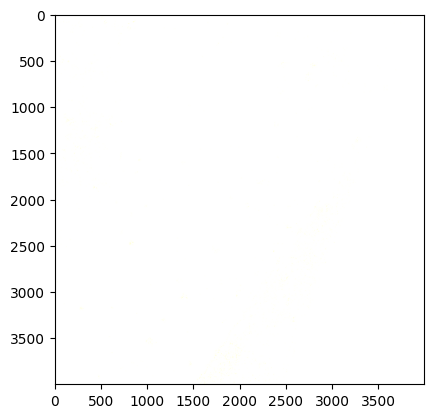

In [38]:
plt.imshow(arr)

(array([6.733000e+03, 2.865000e+03, 3.467000e+03, 3.888000e+03,
        4.429000e+03, 4.791000e+03, 5.453000e+03, 5.952000e+03,
        6.533000e+03, 7.135000e+03, 7.838000e+03, 8.941000e+03,
        9.368000e+03, 1.075200e+04, 1.164500e+04, 1.288500e+04,
        1.391700e+04, 1.500800e+04, 1.647500e+04, 1.784300e+04,
        1.931300e+04, 2.076700e+04, 2.234800e+04, 2.368300e+04,
        2.540100e+04, 2.666700e+04, 2.858100e+04, 3.047100e+04,
        3.182600e+04, 3.379100e+04, 3.466800e+04, 3.700600e+04,
        3.850700e+04, 4.016900e+04, 4.176800e+04, 4.368600e+04,
        4.533600e+04, 4.707900e+04, 4.832100e+04, 4.998800e+04,
        5.190700e+04, 5.405900e+04, 5.537900e+04, 5.708900e+04,
        5.841000e+04, 6.031200e+04, 6.170000e+04, 6.348100e+04,
        6.477400e+04, 6.627800e+04, 6.789600e+04, 6.942900e+04,
        7.018700e+04, 7.191700e+04, 7.337300e+04, 7.483200e+04,
        7.628000e+04, 7.728300e+04, 7.862200e+04, 7.953400e+04,
        8.083800e+04, 8.282400e+04, 8.40

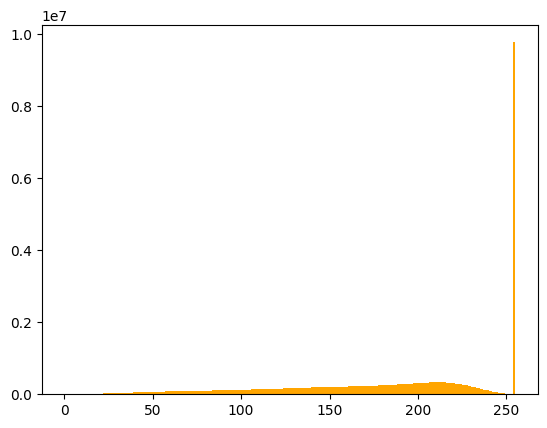

In [39]:
plt.hist(arr.ravel(), bins=256, color='orange', )

In [40]:
with Image.open("dataset/tiles/Flora Pluas RGB/Flora Pluas RGB_1_0_3800_4000_7800.png") as img:
    array = np.array(img)
    

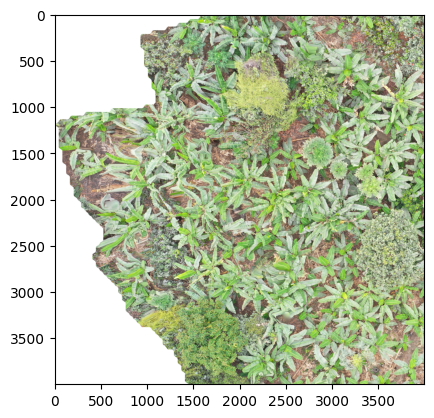

In [41]:
plt.imshow(array)

(array([1.565000e+03, 5.660000e+02, 6.910000e+02, 7.780000e+02,
        8.970000e+02, 9.640000e+02, 1.101000e+03, 1.240000e+03,
        1.400000e+03, 1.627000e+03, 1.857000e+03, 2.057000e+03,
        2.336000e+03, 2.661000e+03, 3.150000e+03, 3.474000e+03,
        4.007000e+03, 4.426000e+03, 5.012000e+03, 5.672000e+03,
        6.324000e+03, 7.100000e+03, 7.638000e+03, 8.593000e+03,
        9.540000e+03, 1.055000e+04, 1.147200e+04, 1.265700e+04,
        1.386000e+04, 1.497000e+04, 1.649400e+04, 1.787600e+04,
        1.990900e+04, 2.108800e+04, 2.307100e+04, 2.495200e+04,
        2.704900e+04, 2.916100e+04, 3.110100e+04, 3.315300e+04,
        3.525600e+04, 3.806700e+04, 4.003500e+04, 4.210400e+04,
        4.484800e+04, 4.758100e+04, 5.027000e+04, 5.244500e+04,
        5.454800e+04, 5.745700e+04, 6.039900e+04, 6.274900e+04,
        6.547500e+04, 6.783000e+04, 7.058700e+04, 7.306100e+04,
        7.571100e+04, 7.843200e+04, 8.111700e+04, 8.442400e+04,
        8.705000e+04, 8.895100e+04, 9.26

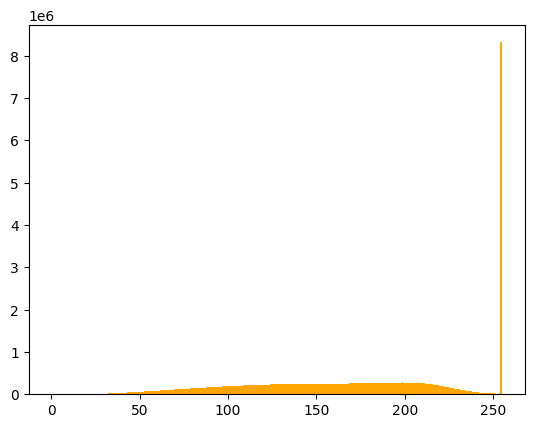

In [43]:
plt.hist(array.ravel(), bins=256, color='orange', )

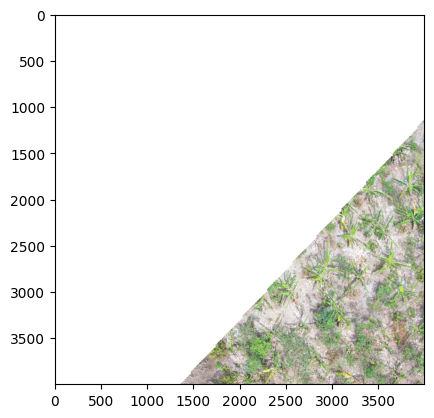

In [ ]:
plt.imshow(ds._load_image(ds.files[0]).permute(2,1,0).numpy())

In [ ]:
from torchgeo.datasets.reforestree import ReforesTree
class Reforest(ReforesTree):
    def __init__(
        self,
        root: Path = 'data',
        transforms: Callable[[dict[str, Tensor]], dict[str, Tensor]] | None = None,
        download: bool = False,
        checksum: bool = False,
    ) -> None:
        super().__init__(root=root, transforms=transforms, download=download, checksum=checksum)

    def plot(
        self,
        sample: dict[str, Tensor],
        show_titles: bool = True,
        suptitle: str | None = None,
    ) -> Figure:
        """Plot a sample from the dataset.

        Args:
            sample: a sample returned by :meth:`__getitem__`
            show_titles: flag indicating whether to show titles above each panel
            suptitle: optional string to use as a suptitle

        Returns:
            a matplotlib Figure with the rendered sample
        """
        image = sample['image'].permute((1, 2, 0)).numpy()
        ncols = 1
        showing_predictions = 'prediction_bbox_xyxy' in sample
        if showing_predictions:
            ncols += 1

        fig, axs = plt.subplots(ncols=ncols, figsize=(ncols * 10, 10))
        if not showing_predictions:
            axs = [axs]

        axs[0].imshow(image)
        axs[0].axis('off')

        bboxes = [
            patches.Rectangle(
                (bbox[0], bbox[1]),
                bbox[2] - bbox[0],
                bbox[3] - bbox[1],
                linewidth=1,
                edgecolor='r',
                facecolor='none',
            )
            for bbox in sample['bbox_xyxy'].numpy()
        ]
        for bbox in bboxes:
            axs[0].add_patch(bbox)

        if show_titles:
            axs[0].set_title('Ground Truth')

        if showing_predictions:
            axs[1].imshow(image)
            axs[1].axis('off')

            pred_bboxes = [
                patches.Rectangle(
                    (bbox[0], bbox[1]),
                    bbox[2] - bbox[0],
                    bbox[3] - bbox[1],
                    linewidth=1,
                    edgecolor='r',
                    facecolor='none',
                )
                for bbox in sample['prediction_bbox_xyxy'].numpy()
            ]
            for bbox in pred_bboxes:
                axs[1].add_patch(bbox)

            if show_titles:
                axs[1].set_title('Predictions')

        if suptitle is not None:
            plt.suptitle(suptitle)

        return fig